In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
dataset = pd.read_csv("UberDataset.csv")
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [57]:
dataset.shape

(1156, 7)

In [58]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [59]:
dataset['PURPOSE'] = dataset['PURPOSE'].fillna("NOT")

In [60]:
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'], errors='coerce')

In [61]:
dataset['date'] = dataset['START_DATE'].dt.date
dataset['time'] = dataset['START_DATE'].dt.hour

dataset['day-night'] = pd.cut(x=dataset['time'],
                              bins=[0,10,15,19,24],
                              labels=['Morning','Afternoon','Evening','Night'])

In [62]:
dataset.dropna(inplace=True)

In [63]:
dataset.drop_duplicates(inplace=True)

In [64]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
unique_values = {}
for col in object_cols:
    unique_values[col] = dataset[col].unique().size
unique_values

{'CATEGORY': 2, 'START': 108, 'STOP': 112, 'PURPOSE': 7, 'date': 113}

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Meal/Entertain'),
  Text(1, 0, 'NOT'),
  Text(2, 0, 'Errand/Supplies'),
  Text(3, 0, 'Meeting'),
  Text(4, 0, 'Customer Visit'),
  Text(5, 0, 'Temporary Site'),
  Text(6, 0, 'Between Offices')])

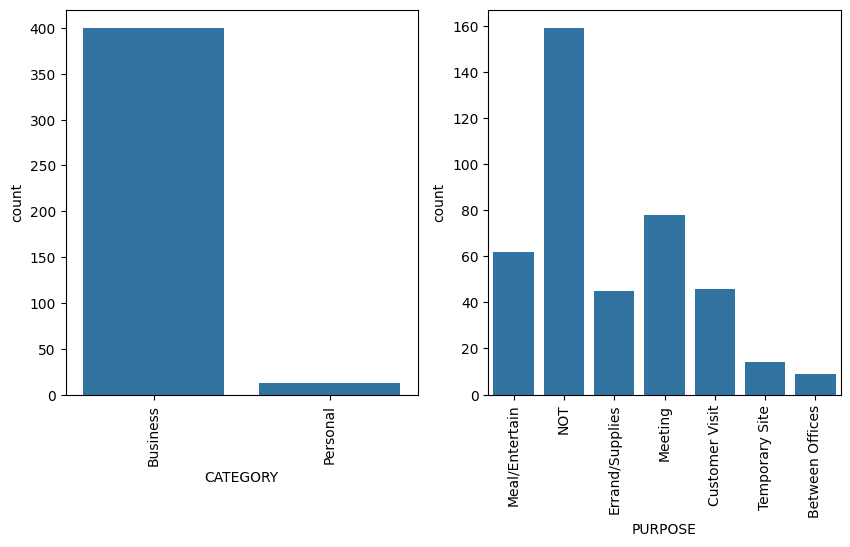

In [65]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(data=dataset, x='CATEGORY')
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.countplot(data=dataset, x='PURPOSE')
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'Morning'),
  Text(1, 0, 'Afternoon'),
  Text(2, 0, 'Evening'),
  Text(3, 0, 'Night')])

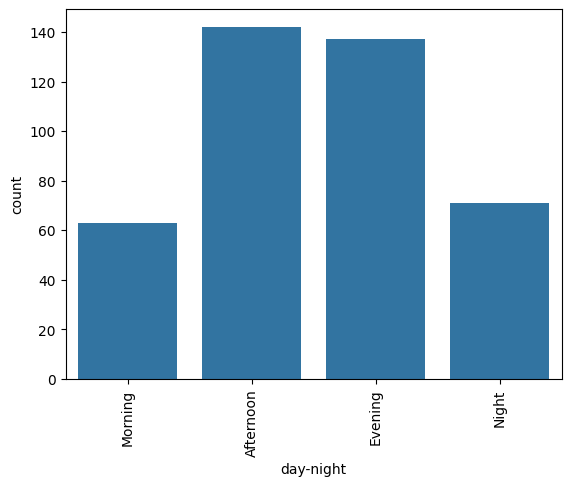

In [66]:
sns.countplot(data=dataset, x='day-night')
plt.xticks(rotation=90)

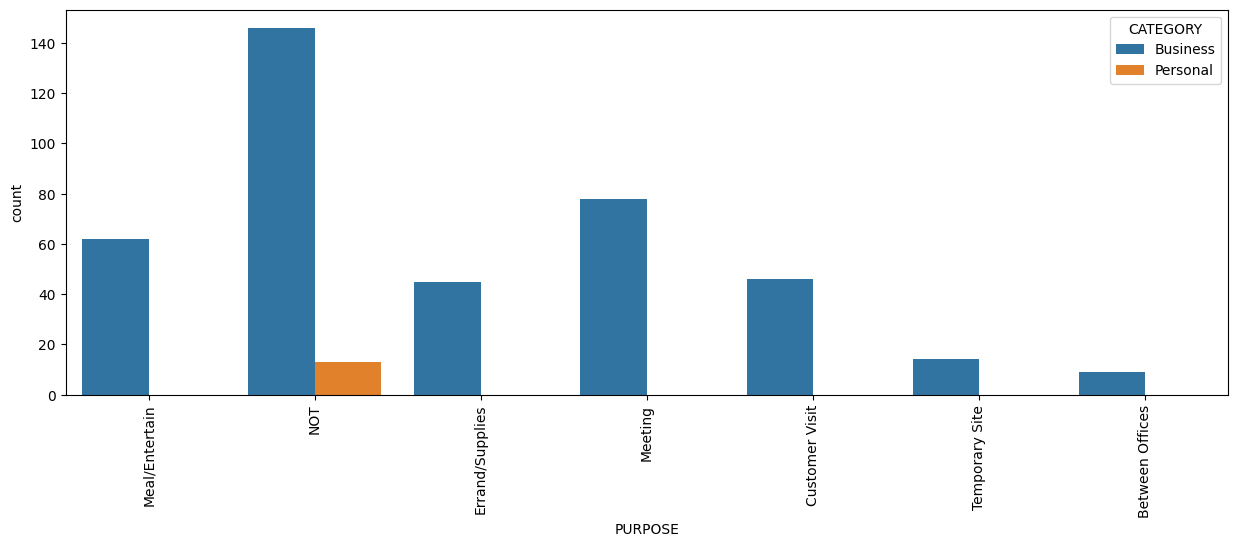

In [67]:
plt.figure(figsize=(15,5))
sns.countplot(data=dataset, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

In [68]:
from sklearn.preprocessing import OneHotEncoder
object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(dataset[object_cols]))
OH_cols.index = dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = dataset.drop(object_cols, axis=1)
dataset = pd.concat([df_final, OH_cols], axis=1)

In [ ]:
numeric_dataset = dataset.select_dtypes(include=['number'])
sns.heatmap(numeric_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)

<Axes: >

In [ ]:
dataset['MONTH'] = dataset['START_DATE'].dt.month
month_label = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'April',
               5: 'May', 6: 'June', 7: 'July', 8: 'Aug',
               9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
dataset["MONTH"] = dataset["MONTH"].map(month_label)

mon = dataset.MONTH.value_counts(sort=False)

# Month total rides count vs Month ride max count
df = pd.DataFrame({"MONTHS": mon.values,
                   "VALUE COUNT": dataset.groupby('MONTH', sort=False)['MILES'].max()})

p = sns.lineplot(data=df)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

In [ ]:
dataset['DAY'] = dataset['START_DATE'].dt.weekday
day_label_map = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thurs', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label_map)

In [ ]:
day_counts = dataset['DAY'].value_counts()
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.xlabel('DAY')
plt.ylabel('COUNT')

In [ ]:
sns.boxplot(y=dataset['MILES'])

In [ ]:
sns.boxplot(y=dataset[dataset['MILES']<100]['MILES'])

In [ ]:
sns.histplot(dataset[dataset['MILES']<40]['MILES'], kde=True, stat='density')